In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [ ]:
import torch
from Configuration import CLASSIFIER_CONFIGURATION, PATH_CONFIGURATION
from Tokenizers.tokenizer import SyllableTokenizer, WordPieceTokenizer
from models.Transformers import PoetEmbedder
from models.MaskingPoetRL import ParallelMaskingPoets, ParallelMaskingPoetsEnv
from models.RewardSystem import PoeticRewardSystem

poets = ParallelMaskingPoets.from_config(
    syl_policy_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_MASKING_POLICY_BASELINE"],
    word_policy_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_MASKING_POLICY_BASELINE"],
    syl_embedder=PoetEmbedder.from_config(
        tokenizer=SyllableTokenizer.from_config(),
        WEIGHT_PATH=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_TRANSFORMER"],
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ).eval(),
    word_embedder=PoetEmbedder.from_config(
        tokenizer=WordPieceTokenizer.from_config(),
        WEIGHT_PATH=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_TRANSFORMER"],
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ).eval(),
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

if __name__ == "__main__":
    # Inserisci qui il tuo testo poetico corrotto o da raffinare


    original_text_2 = """
        Se ni monno esistesse un po' di bene[VERSE] 
        e ognun si considerasse suo fratello[VERSE]  
        ci sarebbe meno pensieri e meno pene[VERSE]
        e il mondo ne sarebbe assai più bello[VERSE]
    """

    original_text_3 = """
        Combattenti di terra, di mare e dell'aria! [VERSE]
        Camicie nere della rivoluzione e delle legioni! [VERSE]
        Uomini e donne d'Italia, dell'Impero e del regno d'Albania! Ascoltate! [VERSE]
        [STANZA]
        L'ora segnata dal destino batte nel cielo della nostra patria. [VERSE] 
        L'ora delle decisioni irrevocabili. [VERSE]
        La dichiarazione di guerra è già stata consegnata agli ambasciatori di Gran Bretagna e di Francia. [VERSE]
    """

    reward_sys = PoeticRewardSystem.from_config(
        syl_embedder=poets.syl_emb,
        word_embedder=poets.word_emb,
        device=poets.device,
    )

    TEXT = original_text_2

    reward_sys.init_reward(
        syl_token_ids=poets.syl_tok.tokenize(TEXT),
        word_token_ids=poets.word_tok.tokenize(TEXT)
    )
    STEPS_PER_EPISODE = 12
    transformed_text, history = poets.autoregressive_forward(
        text=TEXT,
        reward_system=reward_sys,
        top_k=8,
        num_episodes=6,
        steps_per_episode=STEPS_PER_EPISODE,
        quality_threshold_word=0.85,
        quality_threshold_syl=0.85,
    )

    for idx, step in enumerate(history):
        print(f"[Step {idx}] Syl Score: {step['abs_score_syl']:.4f} | Word Score: {step['abs_score_word']:.4f}\nText: {step['text']}\n{'-'*60}")
    
    
    

[INFO] Caricato modello pre-addestrato da './weights/syllable_transformer_weights.pt'
[INFO] Caricato modello pre-addestrato da './weights/wordpiece_transformer_weights.pt'
[INFO] Caricata policy sillabica da './weights/syllable_masking_policy_baseline_weights.pt'
[INFO] Caricata policy wordpiece da './weights/wordpiece_masking_policy_baseline_weights.pt'
[Step 0] Syl Score: 0.4226 | Word Score: 0.3785
Text: l ' inferno e la prima delle tre cantiche in cui e finita la divina commedia.[ verse ] si apre con un canto introduttivo in cui dante presenta la situazione iniziale [ verse ] e illustra le motivazioni del suo viaggio [ verse ] nei tre regni ultraterreni dell ' inferno, del purgatorio e del paradiso. [ verse ] [ stanza ]
------------------------------------------------------------
[Step 1] Syl Score: 0.7422 | Word Score: 0.3783
Text: dell ' inferno e la prima delle tre cantiche in cui e finita la divina commedia.[ verse ] si apre con un canto introduttivo in cui dante presenta la s

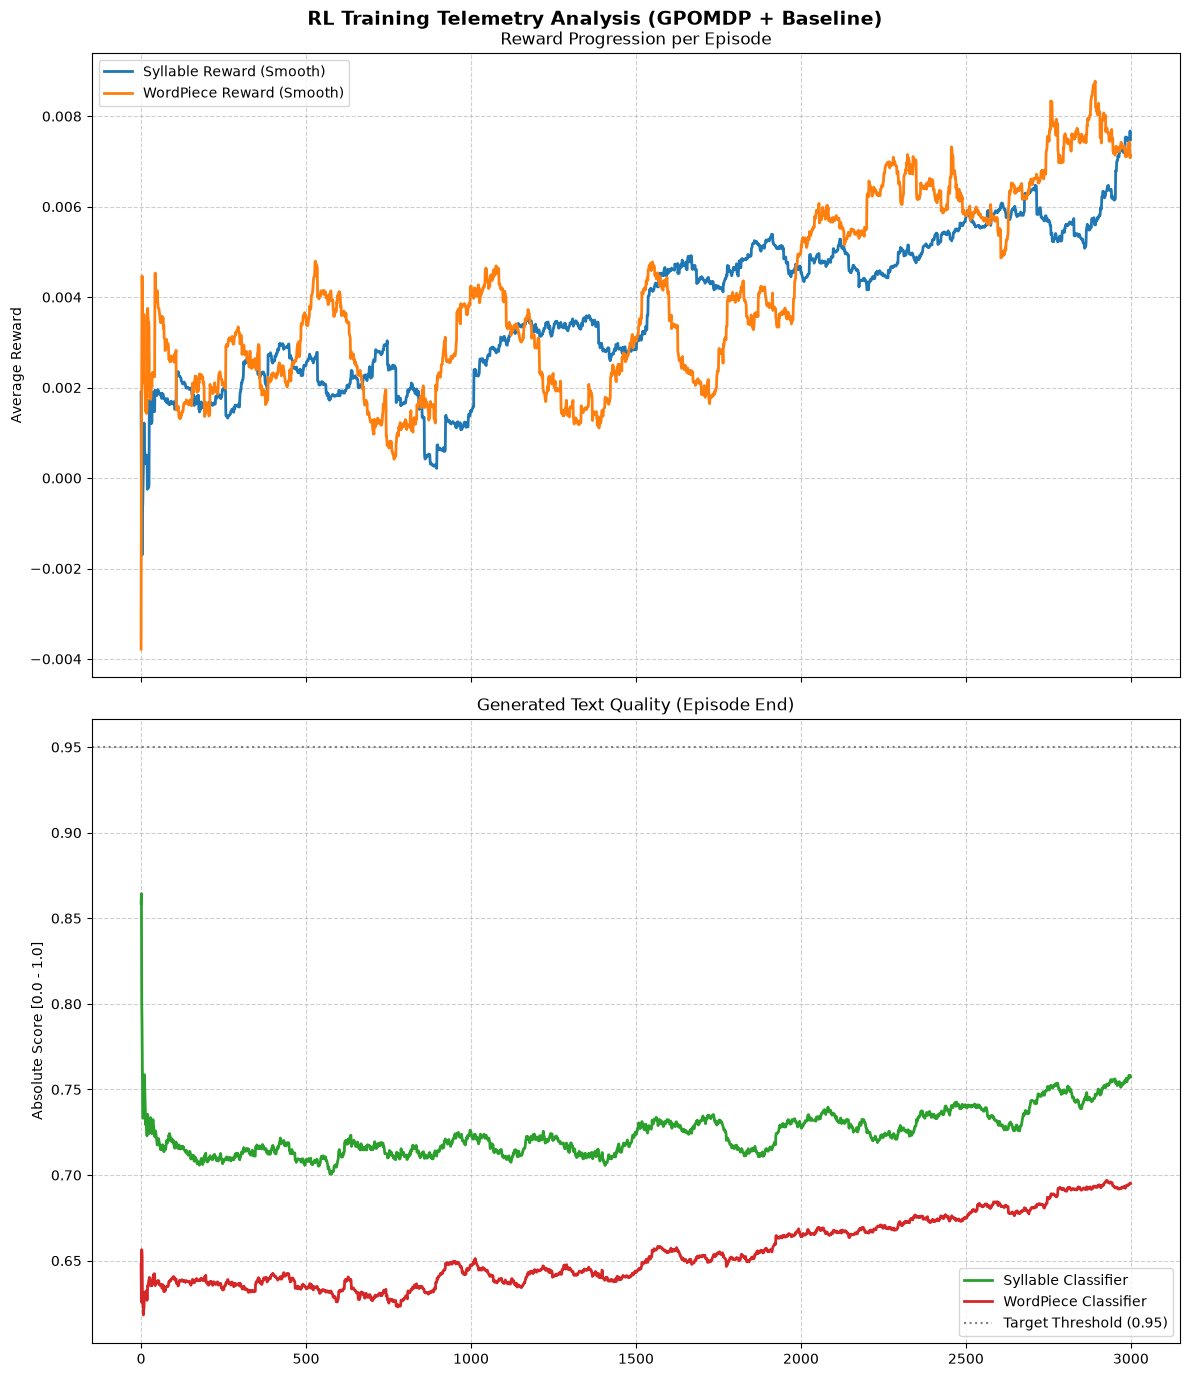

[INFO] Plots successfully generated and saved to 'logs/training_history_baseline_rl_analysis.png'


In [28]:

import pandas as pd
def plot_rl_training_history(history_path: str = "logs/training_history_baseline_rl.pt") -> None:
    """Loads RL training logs from JSON or PyTorch files and plots telemetry charts.

    Reads metrics directly from top-level episode keys (bypassing deleted step logs),
    applies moving average smoothing, and generates plots for rewards, classifier scores, and win counts.

    Args:
        history_path (str): File path to the RL training log (.pt or .json format).
    """
    data: Dict[str, Any] = {}

    # 1. Hybrid loading: Try JSON text format first, then fall back to PyTorch binary dump
    try:
        with open(history_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except (json.JSONDecodeError, UnicodeDecodeError):
        try:
            data = torch.load(history_path, weights_only=False)
        except Exception as e:
            print(f"[ERROR] Failed to load history file '{history_path}': {e}")
            return

    episodes = data.get("episodes", [])
    if not episodes:
        print(f"[ERROR] No episode data found in '{history_path}'")
        return

    # Convert list of episode dictionaries directly into a DataFrame
    df = pd.DataFrame(episodes)

    # Extract metrics directly from episode level attributes
    syl_reward_col = "avg_syl_reward" if "avg_syl_reward" in df.columns else "syl_reward_sum"
    word_reward_col = "avg_word_reward" if "avg_word_reward" in df.columns else "word_reward_sum"

    df["syl_reward"] = df.get(syl_reward_col, 0.0)
    df["word_reward"] = df.get(word_reward_col, 0.0)
    df["final_syl_score"] = df.get("final_syl_classifier_score", 0.0)
    df["final_word_score"] = df.get("final_word_classifier_score", 0.0)

    # Compute moving average smoothing across episodes to reduce visual noise
    window = max(1, len(df) // 20)
    df["syl_reward_smooth"] = df["syl_reward"].rolling(window, min_periods=1).mean()
    df["word_reward_smooth"] = df["word_reward"].rolling(window, min_periods=1).mean()
    df["syl_score_smooth"] = df["final_syl_score"].rolling(window, min_periods=1).mean()
    df["word_score_smooth"] = df["final_word_score"].rolling(window, min_periods=1).mean()

    # 2. Setup figure layout
    fig, axes = plt.subplots(2, 1, figsize=(12, 14), sharex=True)
    fig.suptitle("RL Training Telemetry Analysis (GPOMDP + Baseline)", fontsize=14, fontweight="bold")

    # --- PLOT 1: Episode Average Rewards ---
    axes[0].plot(
        df["syl_reward_smooth"],
        label="Syllable Reward (Smooth)",
        color="tab:blue",
        linewidth=2,
    )
    axes[0].plot(
        df["word_reward_smooth"],
        label="WordPiece Reward (Smooth)",
        color="tab:orange",
        linewidth=2,
    )
    axes[0].set_ylabel("Average Reward")
    axes[0].set_title("Reward Progression per Episode")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    # --- PLOT 2: Final Classifier Scores ---
    axes[1].plot(
        df["syl_score_smooth"],
        label="Syllable Classifier",
        color="tab:green",
        linewidth=2,
    )
    axes[1].plot(
        df["word_score_smooth"],
        label="WordPiece Classifier",
        color="tab:red",
        linewidth=2,
    )
    axes[1].axhline(
        y=0.95,
        color="gray",
        linestyle=":",
        label="Target Threshold (0.95)",
    )
    axes[1].set_ylabel("Absolute Score [0.0 - 1.0]")
    axes[1].set_title("Generated Text Quality (Episode End)")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].legend()

    # --- PLOT 3: Cumulative Wins ---
    df["syl_wins_cum"] = df.get("syl_win_count", 0).cumsum()
    df["word_wins_cum"] = df.get("word_win_count", 0).cumsum()

    output_path =  history_path.replace(".pt", "_analysis.png").replace(".json", "_analysis.png")
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()
    print(f"[INFO] Plots successfully generated and saved to '{output_path}'")


if __name__ == "__main__":
    plot_rl_training_history("logs/training_history_baseline_rl.pt")